# AerisPlane — VLM Flow Visualisation

This notebook demonstrates the flow-field post-processing capabilities of the Vortex Lattice Method solver.

The VLM stores a vortex strength γ on every panel.  After solving, we can:

1. Integrate γ to get the **pressure coefficient ΔCp** on each panel — tells you where the wing is working hard and where it is lightly loaded.
2. Evaluate the **induced velocity field** at any point in space — the horseshoe singularities give an exact analytic expression for the velocity induced by every vortex filament in the mesh.

From the induced field we build two types of streamline plots:
- **XZ symmetry plane** — shows upwash ahead of the leading edge and the downwash wake behind the trailing edge.
- **YZ rear cross-section** — a slice perpendicular to the flight direction behind the wing; the two counter-rotating **tip vortices** appear as swirling rings.

All plots are available as methods on `AeroResult`:

| Method | Description |
|---|---|
| `result.plot_surface_pressure()` | ΔCp on panels — 3-D + top-down |
| `result.plot_streamlines("xz")` | Upwash/downwash in the symmetry plane |
| `result.plot_streamlines("yz")` | Tip-vortex crossflow behind the TE |
| `result.plot_flow()` | All four panels in one dark-background figure |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import aerisplane as ap
from aerisplane.aero import analyze

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

---
## 1 — Aircraft

Same CoreFly configuration used in tutorial 02.

In [2]:
# ── Airfoils ──────────────────────────────────────────────────────────────
ag35     = ap.Airfoil(name="ag35")
naca0009 = ap.Airfoil.from_naca("0009")

# ── Main wing: tapered, 3 sections, −2° washout at tip ────────────────────
main_wing = ap.Wing(
    name="main_wing",
    xsecs=[
        ap.WingXSec(xyz_le=[0.00, 0.00, 0.00], chord=0.28, twist= 0.0, airfoil=ag35),
        ap.WingXSec(xyz_le=[0.03, 0.60, 0.02], chord=0.21, twist=-1.0, airfoil=ag35),
        ap.WingXSec(xyz_le=[0.07, 1.20, 0.05], chord=0.14, twist=-2.0, airfoil=ag35),
    ],
    symmetric=True,
)

# ── Horizontal tail ───────────────────────────────────────────────────────
htail = ap.Wing(
    name="htail",
    xsecs=[
        ap.WingXSec(xyz_le=[0.95, 0.00, 0.00], chord=0.10, airfoil=naca0009),
        ap.WingXSec(xyz_le=[0.97, 0.28, 0.00], chord=0.07, airfoil=naca0009),
    ],
    symmetric=True,
)

aircraft = ap.Aircraft(
    name="CoreFly",
    wings=[main_wing, htail],
)

mw = aircraft.main_wing()
print(f"Wing area  : {mw.area():.4f} m²")
print(f"Wing span  : {mw.span():.4f} m")
print(f"AR         : {mw.aspect_ratio():.2f}")
print(f"MAC        : {mw.mean_aerodynamic_chord():.4f} m")

Wing area  : 0.5040 m²
Wing span  : 2.4000 m
AR         : 11.43
MAC        : 0.2217 m


---
## 2 — Baseline VLM run

Cruise condition: V = 16 m/s, h = 0 m, α = 4°.

In [3]:
cond = ap.FlightCondition(velocity=16.0, altitude=0.0, alpha=4.0)

result = analyze(
    aircraft, cond,
    method="vlm",
    spanwise_resolution=12,
    chordwise_resolution=6,
)
result.report()

----------------------------------------------------
  AeroResult — method: vlm
----------------------------------------------------
  Operating point:
    alpha          =     4.0000  deg
    beta           =     0.0000  deg
    velocity       =    16.0000  m/s
    altitude       =        0.0  m
    dyn. pressure  =     156.80  Pa
    Reynolds (MAC) =     242810
----------------------------------------------------
  Reference geometry:
    S_ref = 0.5040 m^2   c_ref = 0.2217 m   b_ref = 2.4000 m
----------------------------------------------------
  Force coefficients (wind axes):
    CL   =   0.606051
    CD   =   0.009933
    CDi  =   0.009933  (induced)
    CY   =   0.000000
----------------------------------------------------
  Moment coefficients (body axes):
    Cl   =  -0.000000  (roll)
    Cm   =  -0.322749  (pitch)
    Cn   =  -0.000000  (yaw)
----------------------------------------------------
  Forces (wind axes):
    L    =     47.894  N
    D    =      0.785  N
    Y    

---
## 3 — Surface pressure (ΔCp)

The pressure coefficient on each panel is computed from the panel's vortex strength and normal force:

$$\Delta C_p = \frac{F_\perp}{q \, A}$$

- **Red** = suction (upper surface, ΔCp > 0) — wing is generating lift here.
- **Blue** = pressure (lower surface or lightly loaded region).

The leading-edge region always carries the highest suction; loading tapers toward the tip due to the induced downwash from the trailing vortices.

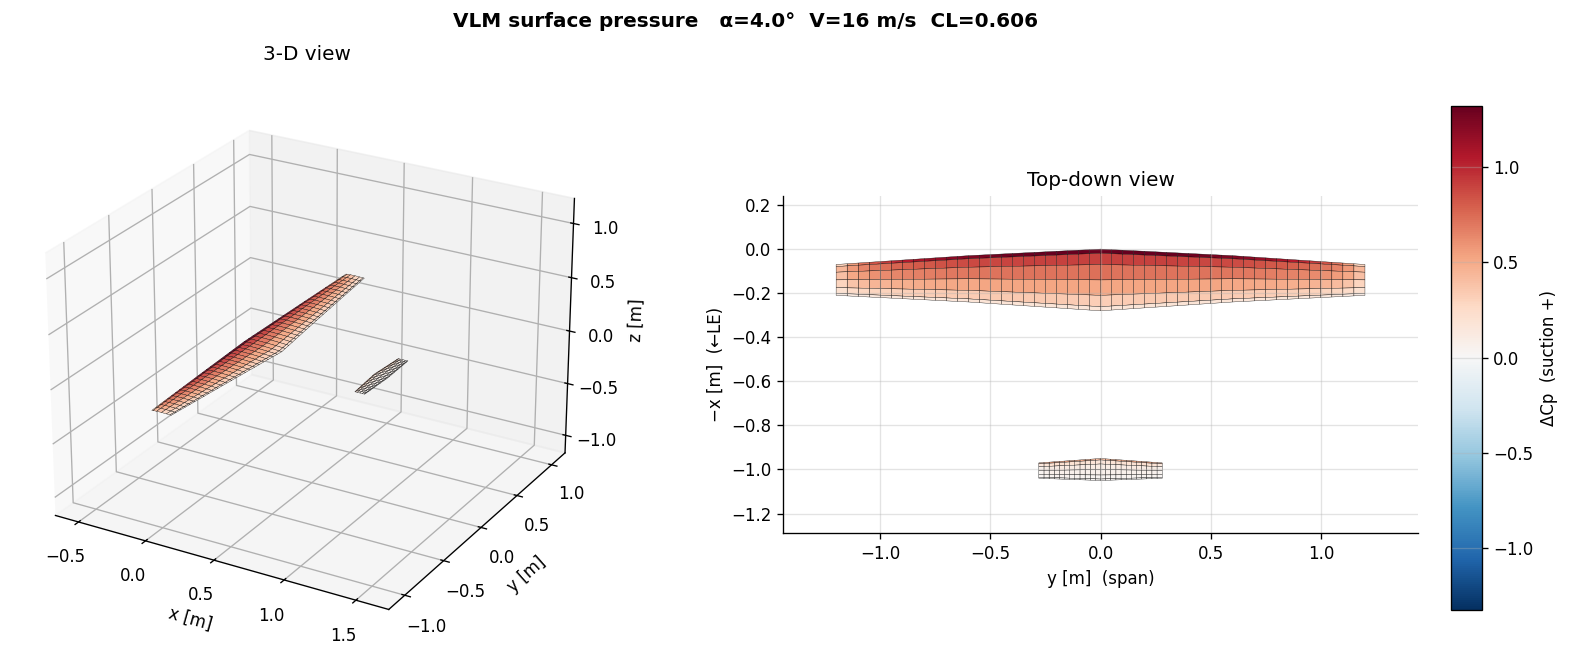

In [4]:
result.plot_surface_pressure()

---
## 4 — Symmetry-plane streamlines (XZ)

A 2-D grid of points is placed in the **y = 0 plane** (the aircraft symmetry plane).  The VLM evaluates the induced velocity at each grid point from all horseshoe vortices in the mesh.  The freestream is subtracted to reveal the **perturbation field** — otherwise the large freestream velocity (16 m/s) would swamp the induced velocities (≈ 0.1–0.5 m/s) and the streamlines would look like parallel horizontal lines.

What to look for:
- **Upwash** (Vz > 0, lines curve upward) ahead of the leading edge.
- **Downwash** (Vz < 0, lines curve downward) behind the trailing edge —   this is what reduces the effective angle of attack on a real tail.

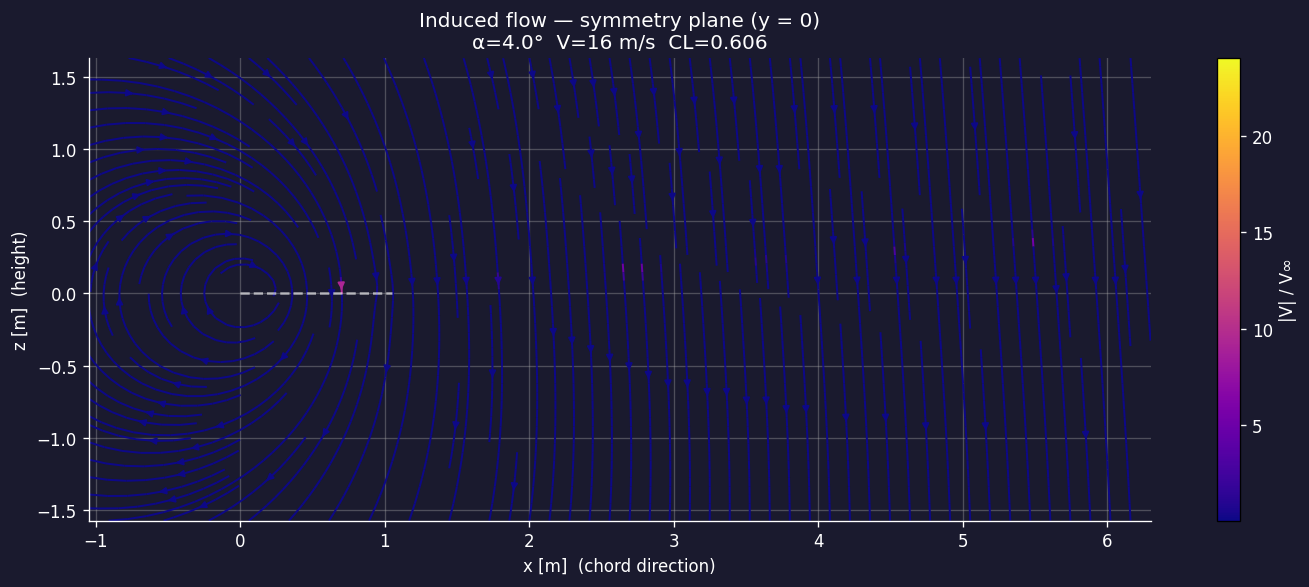

In [5]:
result.plot_streamlines(plane="xz")

---
## 5 — Tip-vortex crossflow (YZ)

A vertical slice perpendicular to the flight direction is placed **2 chord lengths behind the trailing edge**.  The y- and z-components of the induced velocity are plotted as streamlines.

The two **tip vortices** appear as counter-rotating rings:
- Right tip vortex: rotates clockwise when viewed from behind.
- Left tip vortex: rotates counter-clockwise.

Between them the downwash is strongest — this is the induced-drag penalty. The vortex core is tightest just behind the tip and diffuses with distance.

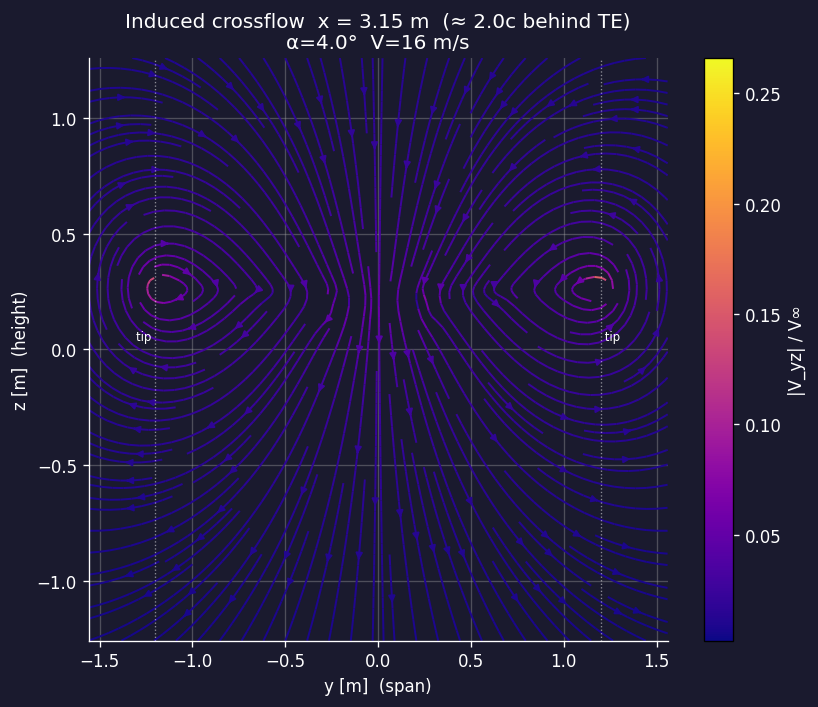

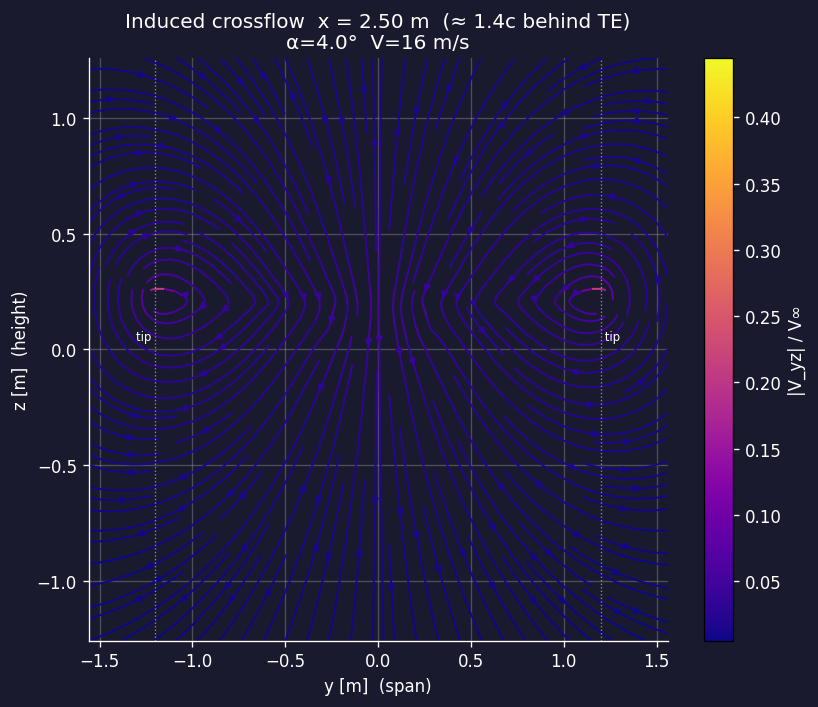

In [6]:
result.plot_streamlines(plane="yz")

# Optionally inspect different downstream distances
result.plot_streamlines(plane="yz", x_slice=2.5)   # ~10c behind TE

---
## 6 — Combined flow figure

All four panels in a single dark-background figure.

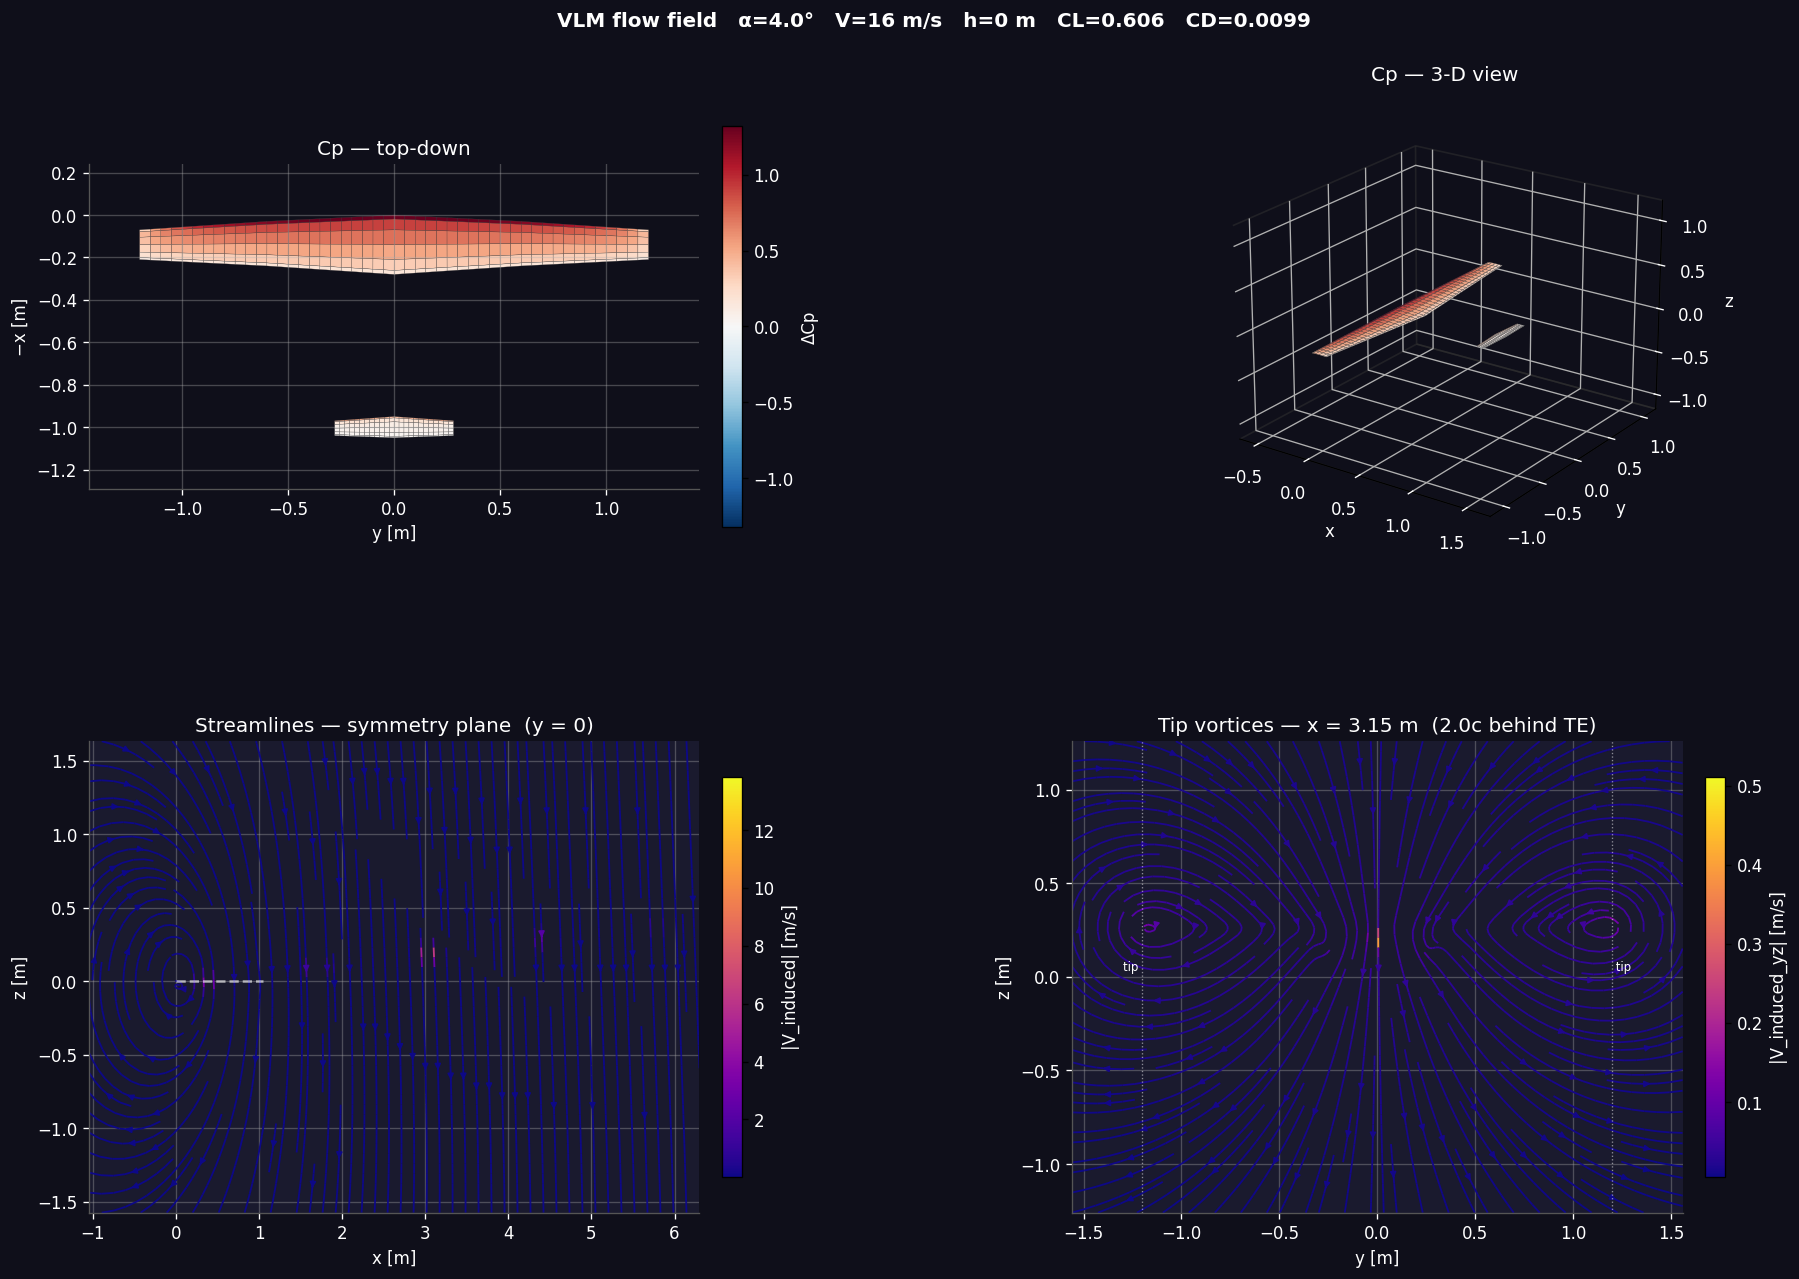

In [7]:
result.plot_flow()

---
## 7 — Effect of angle of attack

How does the flow field change as α increases?  We run VLM at three angles and compare the surface Cp and the symmetry-plane streamlines.

In [8]:
alphas = [0.0, 4.0, 10.0]
alpha_results = {
    a: analyze(aircraft,
               ap.FlightCondition(velocity=16.0, altitude=0.0, alpha=a),
               method="vlm", spanwise_resolution=12, chordwise_resolution=6)
    for a in alphas
}
for a, r in alpha_results.items():
    print(f"α = {a:5.1f}°   CL = {r.CL:.3f}   CD = {r.CD:.5f}   Cm = {r.Cm:.4f}")

α =   0.0°   CL = 0.219   CD = 0.00132   Cm = -0.0917
α =   4.0°   CL = 0.606   CD = 0.00993   Cm = -0.3227
α =  10.0°   CL = 1.194   CD = 0.03882   Cm = -0.6956


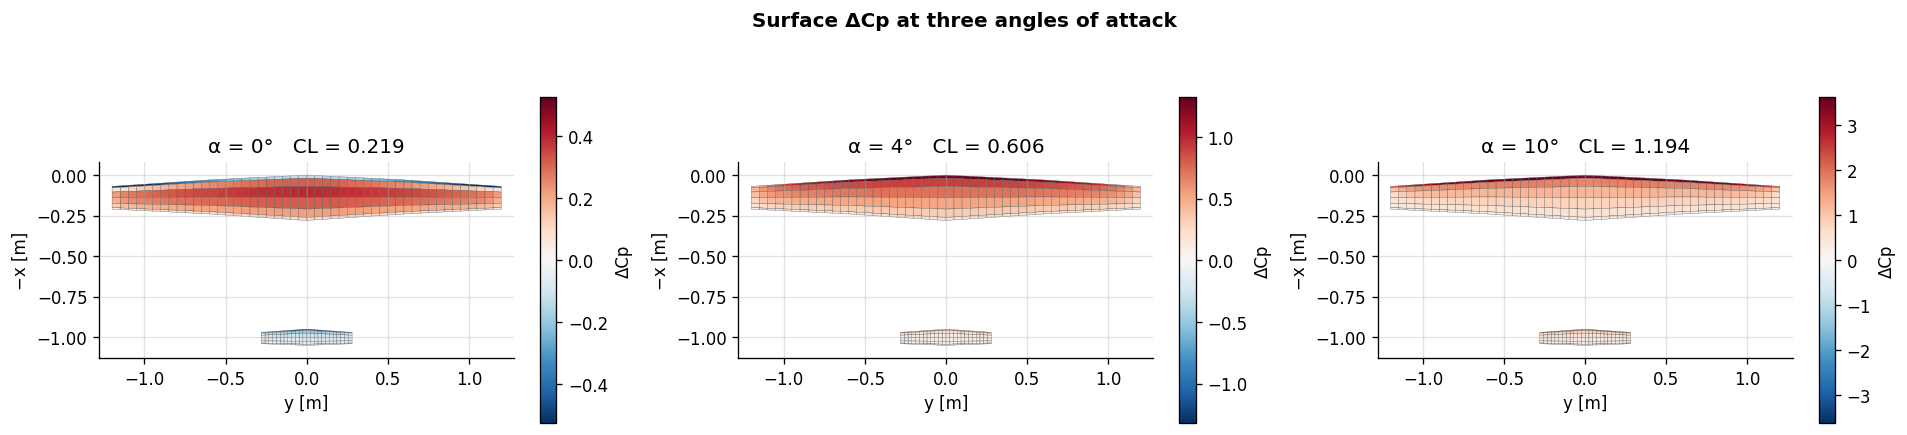

In [9]:
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors
import numpy as np
from aerisplane.aero.flow_viz import _panel_cp, _wing_bounds

# Side-by-side Cp top-down for each alpha
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Surface ΔCp at three angles of attack", fontsize=12, fontweight="bold")

for ax, (a, r) in zip(axes, alpha_results.items()):
    vlm = r._solver
    Cp  = _panel_cp(vlm, r.dynamic_pressure)
    fl  = vlm.front_left_vertices
    bl  = vlm.back_left_vertices
    br  = vlm.back_right_vertices
    fr  = vlm.front_right_vertices
    mn, mx = _wing_bounds(vlm)

    verts = np.stack([fl, bl, br, fr], axis=1)
    verts_2d = verts[:, :, [1, 0]].copy()
    verts_2d[:, :, 1] = -verts_2d[:, :, 1]

    vmax = max(np.percentile(np.abs(Cp), 98), 0.1)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    poly = PolyCollection(verts_2d, cmap="RdBu_r", norm=norm,
                          linewidths=0.2, edgecolors="#555")
    poly.set_array(Cp)
    ax.add_collection(poly)
    pad = 0.08
    ax.set_xlim(mn[1]-pad, mx[1]+pad)
    ax.set_ylim(-mx[0]-pad, -mn[0]+pad)
    ax.set_aspect("equal")
    ax.set_xlabel("y [m]"); ax.set_ylabel("−x [m]")
    ax.set_title(f"α = {a:.0f}°   CL = {r.CL:.3f}")
    fig.colorbar(poly, ax=ax, shrink=0.8, label="ΔCp")

plt.tight_layout()

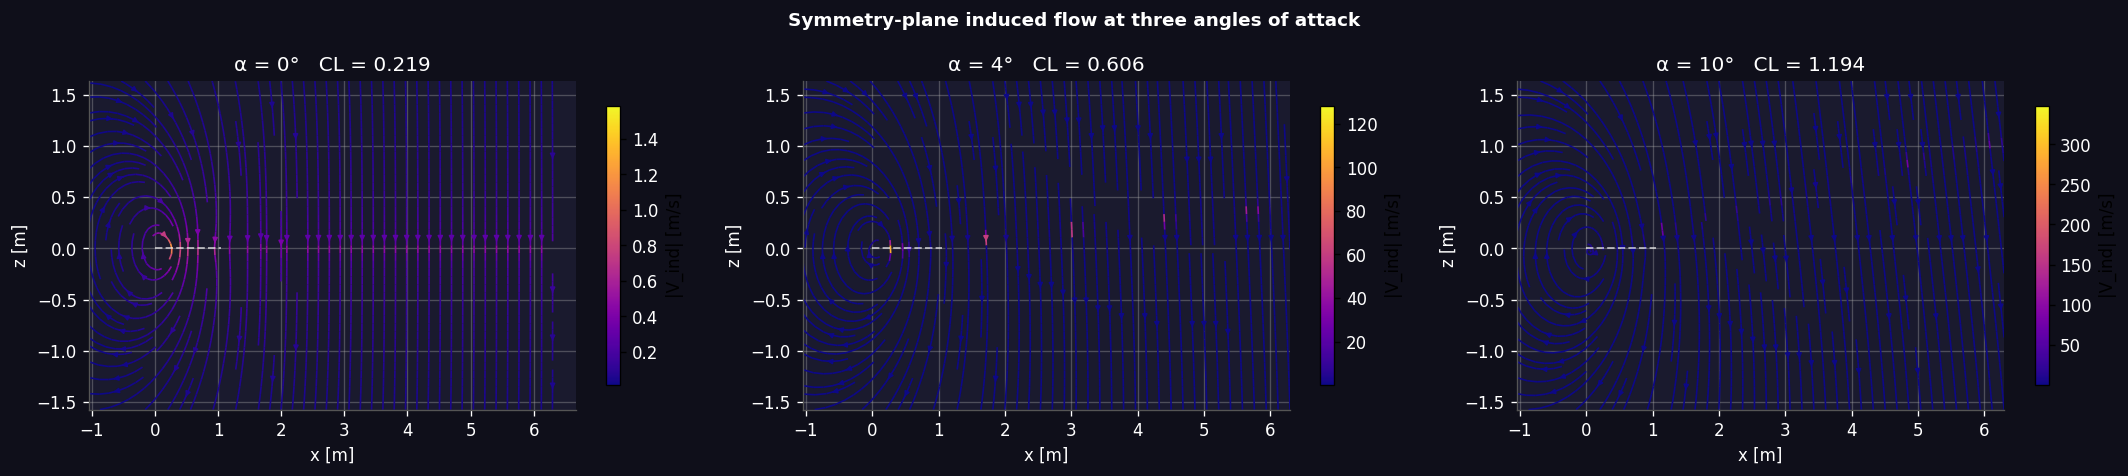

In [10]:
from aerisplane.aero.flow_viz import _velocity_grid_xz

# XZ streamlines for each alpha on a shared figure
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor("#0f0f1a")
fig.suptitle("Symmetry-plane induced flow at three angles of attack",
             fontsize=11, fontweight="bold", color="white")

for ax, (a, r) in zip(axes, alpha_results.items()):
    vlm = r._solver
    xg, zg, Vx, Vz, speed = _velocity_grid_xz(vlm, n_x=50, n_z=35)
    ax.set_facecolor("#1a1a2e")
    strm = ax.streamplot(xg, zg, Vx, Vz,
                         color=speed, cmap="plasma",
                         linewidth=1.0, density=1.4, arrowsize=0.6)
    # Wing chord dashes
    fl = vlm.front_left_vertices
    bl = vlm.back_left_vertices
    root = np.abs(fl[:, 1]) < np.abs(fl[:, 1]).max() * 0.15
    if root.any():
        ax.plot([fl[root, 0].min(), bl[root, 0].max()],
                [fl[root, 2].mean(), fl[root, 2].mean()],
                color="white", lw=1.2, ls="--", alpha=0.6)
    ax.set_xlabel("x [m]", color="white")
    ax.set_ylabel("z [m]", color="white")
    ax.set_title(f"α = {a:.0f}°   CL = {r.CL:.3f}", color="white")
    ax.tick_params(colors="white")
    for sp in ax.spines.values(): sp.set_edgecolor("#555")
    fig.colorbar(strm.lines, ax=ax, shrink=0.85,
                 label="|V_ind| [m/s]").ax.tick_params(labelcolor="white")

plt.tight_layout()

---
## 8 — Interactive 3-D visualisation

`result.plot_interactive()` builds a Plotly figure that you can **rotate, zoom, and pan**
in the browser or inside Jupyter.  It combines:

- Wing surface coloured by **ΔCp** (same RdBu_r scale as the static plots)
- **3-D streamlines** traced through the full velocity field with RK4 integration,
  seeded on a span × z grid one chord upstream of the leading edge

The streamlines reveal the three-dimensional structure of the flow:
how air from in front of the wing tip is deflected inboard and upward,
rolls up into a tip vortex, and spirals behind the trailing edge.

In [11]:
# Interactive Plotly figure — rotate / zoom in the output cell
result.plot_interactive(n_streamlines=40)

To save a standalone interactive HTML file:

```python
result.plot_interactive(save_path="flow_interactive.html")
```

The file can be opened in any browser without a Python kernel.

---
## Summary

### What the plots show

| Plot | Physical meaning |
|---|---|
| **ΔCp top-down** | Where the wing is generating lift (red = suction = upper surface working). High loading near root and LE; taper toward tip. |
| **ΔCp 3-D** | Same data on the wing surface in perspective. |
| **XZ streamlines** | Induced perturbation in the symmetry plane. Upwash ahead of the LE, downwash aft of the TE. The tail sits in this downwash — a key stability effect. |
| **YZ crossflow** | Tip vortex swirl behind the TE. Counter-rotating pair. The stronger the vortex (higher CL), the more intense the rotation. |

### API

```python
result = analyze(aircraft, condition, method="vlm")

result.plot_surface_pressure()
result.plot_streamlines("xz")
result.plot_streamlines("yz")
result.plot_streamlines("yz", x_slice=2.5)   # custom downstream distance [m]
result.plot_flow()                            # all four in one figure
result.plot_interactive()                     # interactive Plotly 3-D
result.plot_interactive(save_path="flow.html")  # save standalone HTML
```

All methods accept `show=True/False` and `save_path="file.png"`.